/home/mclab/miniconda3/envs/ydl/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Model training completed.


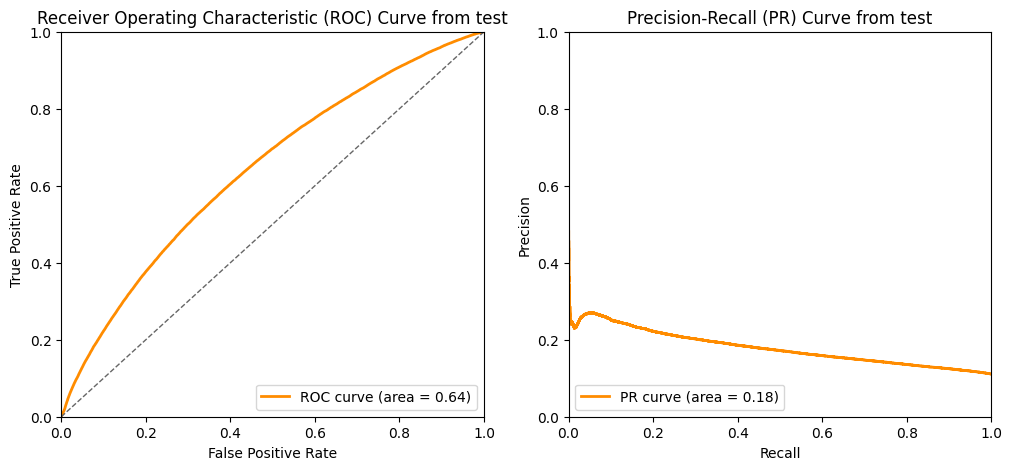

AUROC: 0.6415
AUPRC: 0.1789


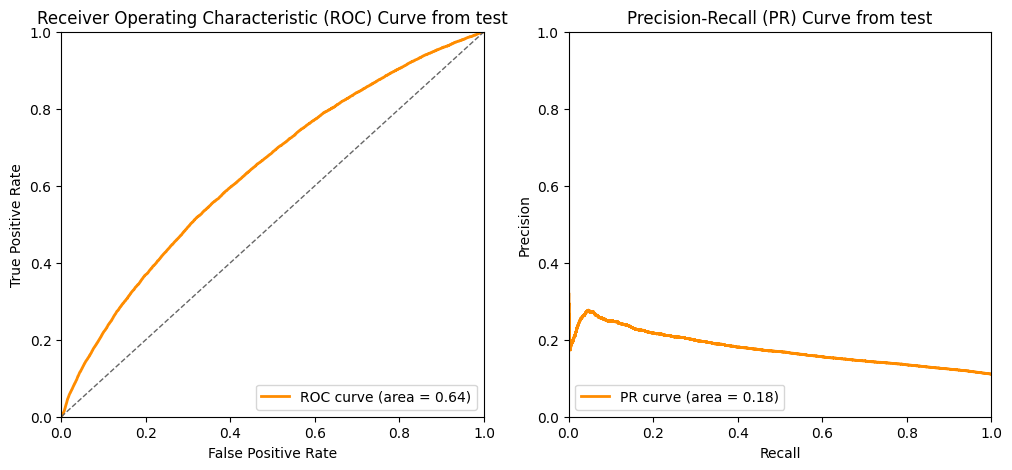

AUROC: 0.6362
AUPRC: 0.1755


[np.float64(0.6362431424263696),
 np.float64(0.6301056411446263),
 np.float64(0.6436846097233281),
 0.8694549773859016,
 0.08994490358126722,
 0.9663482116869553,
 0.24937941569600916,
 0.8952076575969293,
 0.13220630662549981]

In [2]:
from xgboost import XGBClassifier
from ehr_models import *
import ehr_utils
import pandas as pd
# drop mean bayesian
fill_method = 'mean'

file_path = f'data_cleaned/ver-noelectrolyte-logtransform_{fill_method}.csv'

X_train, X_test, Y_train, Y_test = ehr_utils.get_train_test(file_path, train_size=0.8, random_state=42)
# 使用 SMOTE 进行过采样
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
smote = SMOTE(random_state=42)
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train, Y_train)
## 需要测试哪个模型就取消注释对应的行,需要默认参数default=True，需要优化后的参数 默认=false
default = False
# model = init_adaBoost(default_parm=default)
# model = init_decisionTree(default_parm=default)
# model = init_gaussianNB(default_parm=default)
# model = init_gradientBoosting(default_parm=default)
# model = init_lightGBM(default_parm=default)
# model = init_linearDiscriminantAnalysis(default_parm=default)
# model = init_logisticRegression(default_parm=default)
model = init_MLPClassifier(default_parm=default)
# model = init_randomForest(default_parm=default)
# model = init_XGBoost(default_parm=default)
# model.fit(X_train, Y_train)
model.fit(X_train_resampled, Y_train_resampled)
print("Model training completed.")
Y_prob, Y_pred = ehr_utils.get_prediction_results(model, X_test)
Ytrain_prob, Ytrain_pred = ehr_utils.get_prediction_results(model, X_train)
ehr_utils.plot_roc_pr_curves(Y_train, Ytrain_prob, 'dt')
ehr_utils.plot_roc_pr_curves(Y_test, Y_prob, 'xgb')
ehr_utils.eval_model(Y_test, Y_prob, Y_pred)

In [ ]:
import pickle
with open(f'trained_models_default/{fill_method}/DecisionTree_0.65.pkl', 'wb') as f:
    pickle.dump(model, f)